# OSM Commercial — Visualization

Reads the most recent `osm_distances_*.csv` generated by `osm_commercial_by_distances.ipynb` and renders:

| Cell | Content |
|---|---|
| 2 | Load data |
| 3 | Bar chart — top commercial categories + donut by tag type |
| 4 | Histograms — proximity distance distributions |
| 5 | Box plots — proximity distances by commercial category |
| 6 | Scatter — distance from origin vs. distance to transit |
| 7 | Correlation matrix — all distance metrics |
| 8 | **Interactive map** — clustered markers, popups, layer control |
| 9 | **Heatmap** — commercial density |
| 10 | **Proximity map** — features colored by distance to transit |
| 11 | Statistical summary table |

---
- Run cells **top to bottom**
- No parameters to edit — the notebook auto-loads the latest CSV
- Kernel: **OSMnx Scraper (Python 3.11)**

## Cell 1 · Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, HeatMap, MeasureControl
import glob
import os

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print(f"pandas     {pd.__version__}")
print(f"matplotlib {plt.matplotlib.__version__}")
print(f"seaborn    {sns.__version__}")
print(f"folium     {folium.__version__}")


pandas     3.0.2
matplotlib 3.10.9
seaborn    0.13.2
folium     0.20.0


## Cell 2 · Load Data

Auto-loads the most recent `osm_distances_*.csv` file.

In [2]:
# ── Loads the most recent osm_distances_*.csv automatically ──────────────────
files = sorted(glob.glob("osm_distances_*.csv"))
if not files:
    raise FileNotFoundError(
        "No osm_distances_*.csv found. "
        "Run osm_commercial_by_distances.ipynb first."
    )

CSV_PATH = files[-1]   # most recent file
df = pd.read_csv(CSV_PATH)

# Derived column: primary_tag group color (used across several plots)
TAG_COLORS = {
    "shop":    "#e74c3c",
    "amenity": "#3498db",
    "office":  "#9b59b6",
    "craft":   "#e67e22",
    "tourism": "#1abc9c",
    "leisure": "#f1c40f",
}
df["tag_color"] = df["primary_tag"].map(TAG_COLORS).fillna("#95a5a6")

# Origin coordinates (center of the scrape)
ORIGIN_LAT = df.attrs.get("origin_lat", df["lat"].mean())
ORIGIN_LON = df.attrs.get("origin_lon", df["lon"].mean())
# Fallback: compute centroid from data
ORIGIN_LAT = df["lat"].mean()
ORIGIN_LON = df["lon"].mean()

print(f"Loaded : {CSV_PATH}")
print(f"Rows   : {len(df)}")
print(f"Columns: {list(df.columns)}")


Loaded : osm_distances_001_2026-04-30_16-38-31.csv
Rows   : 3704
Columns: ['osm_id', 'osm_type', 'lat', 'lon', 'distance_m', 'primary_tag', 'primary_value', 'name', 'brand', 'shop', 'amenity', 'office', 'craft', 'tourism', 'leisure', 'cuisine', 'opening_hours', 'phone', 'website', 'wheelchair', 'outdoor_seating', 'takeaway', 'delivery', 'level', 'addr_street', 'addr_housenumber', 'addr_postcode', 'has_name', 'distance_band', 'dist_transit_m', 'nearest_transit', 'dist_hospital_m', 'nearest_hospital', 'dist_school_m', 'nearest_school', 'dist_park_m', 'nearest_park', 'tag_color']


## Cell 3 · Commercial Categories

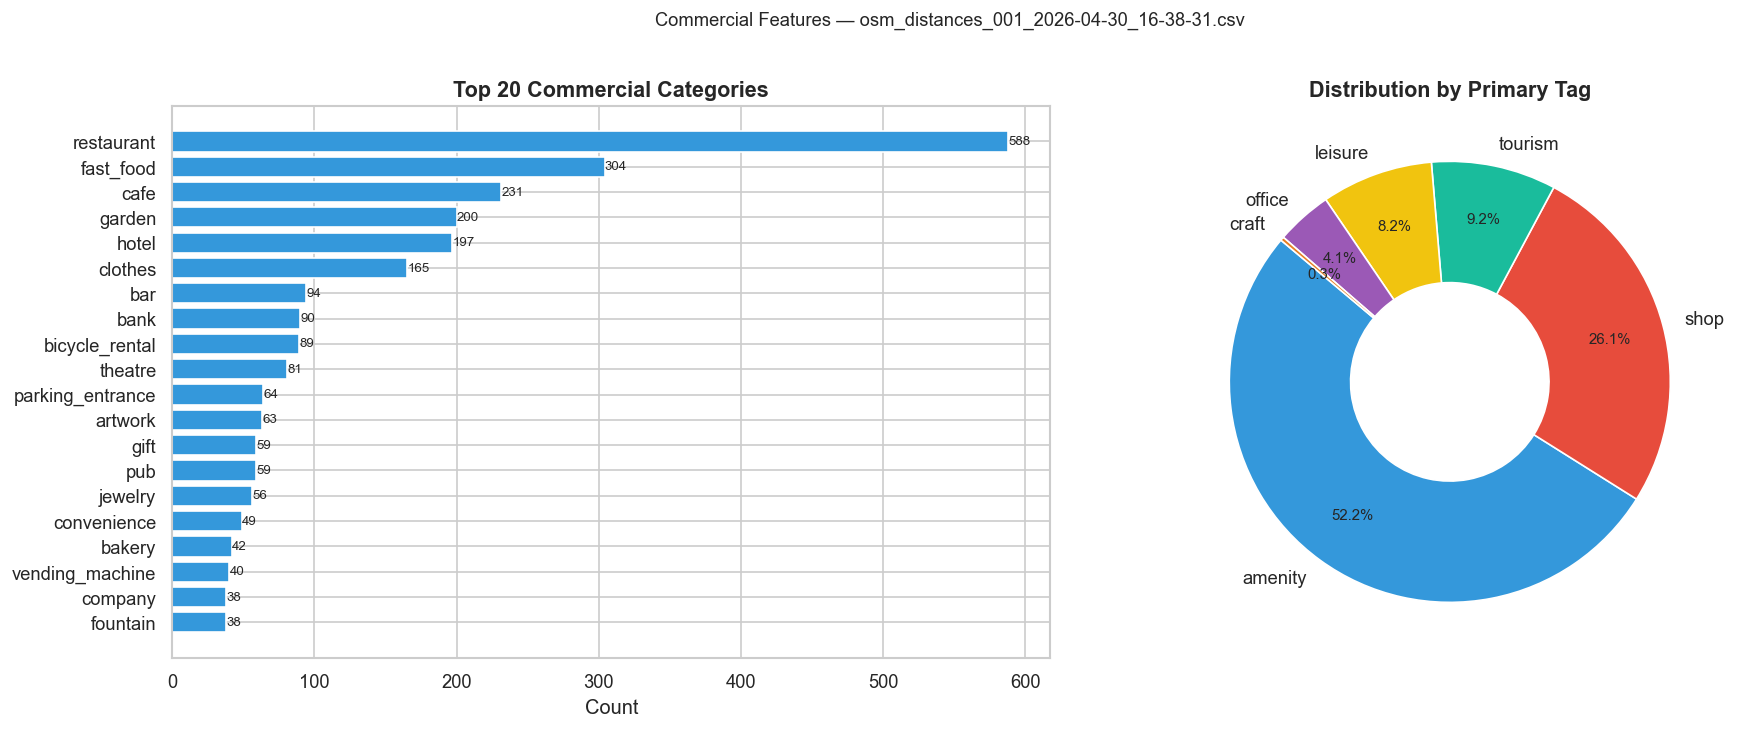

In [3]:
# ── Top 20 commercial categories (bar chart) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top 20 primary_value
top_vals = df["primary_value"].value_counts().head(20)
axes[0].barh(top_vals.index[::-1], top_vals.values[::-1], color="#3498db")
axes[0].set_title("Top 20 Commercial Categories", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")
for i, v in enumerate(top_vals.values[::-1]):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=8)

# Right: primary_tag distribution (donut)
tag_counts = df["primary_tag"].value_counts()
colors = [TAG_COLORS.get(t, "#95a5a6") for t in tag_counts.index]
wedges, texts, autotexts = axes[1].pie(
    tag_counts.values, labels=tag_counts.index, colors=colors,
    autopct="%1.1f%%", pctdistance=0.75, startangle=140,
    wedgeprops=dict(width=0.55)
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title("Distribution by Primary Tag", fontsize=13, fontweight="bold")

plt.suptitle(f"Commercial Features — {os.path.basename(CSV_PATH)}", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## Cell 4 · Proximity Distance Distributions

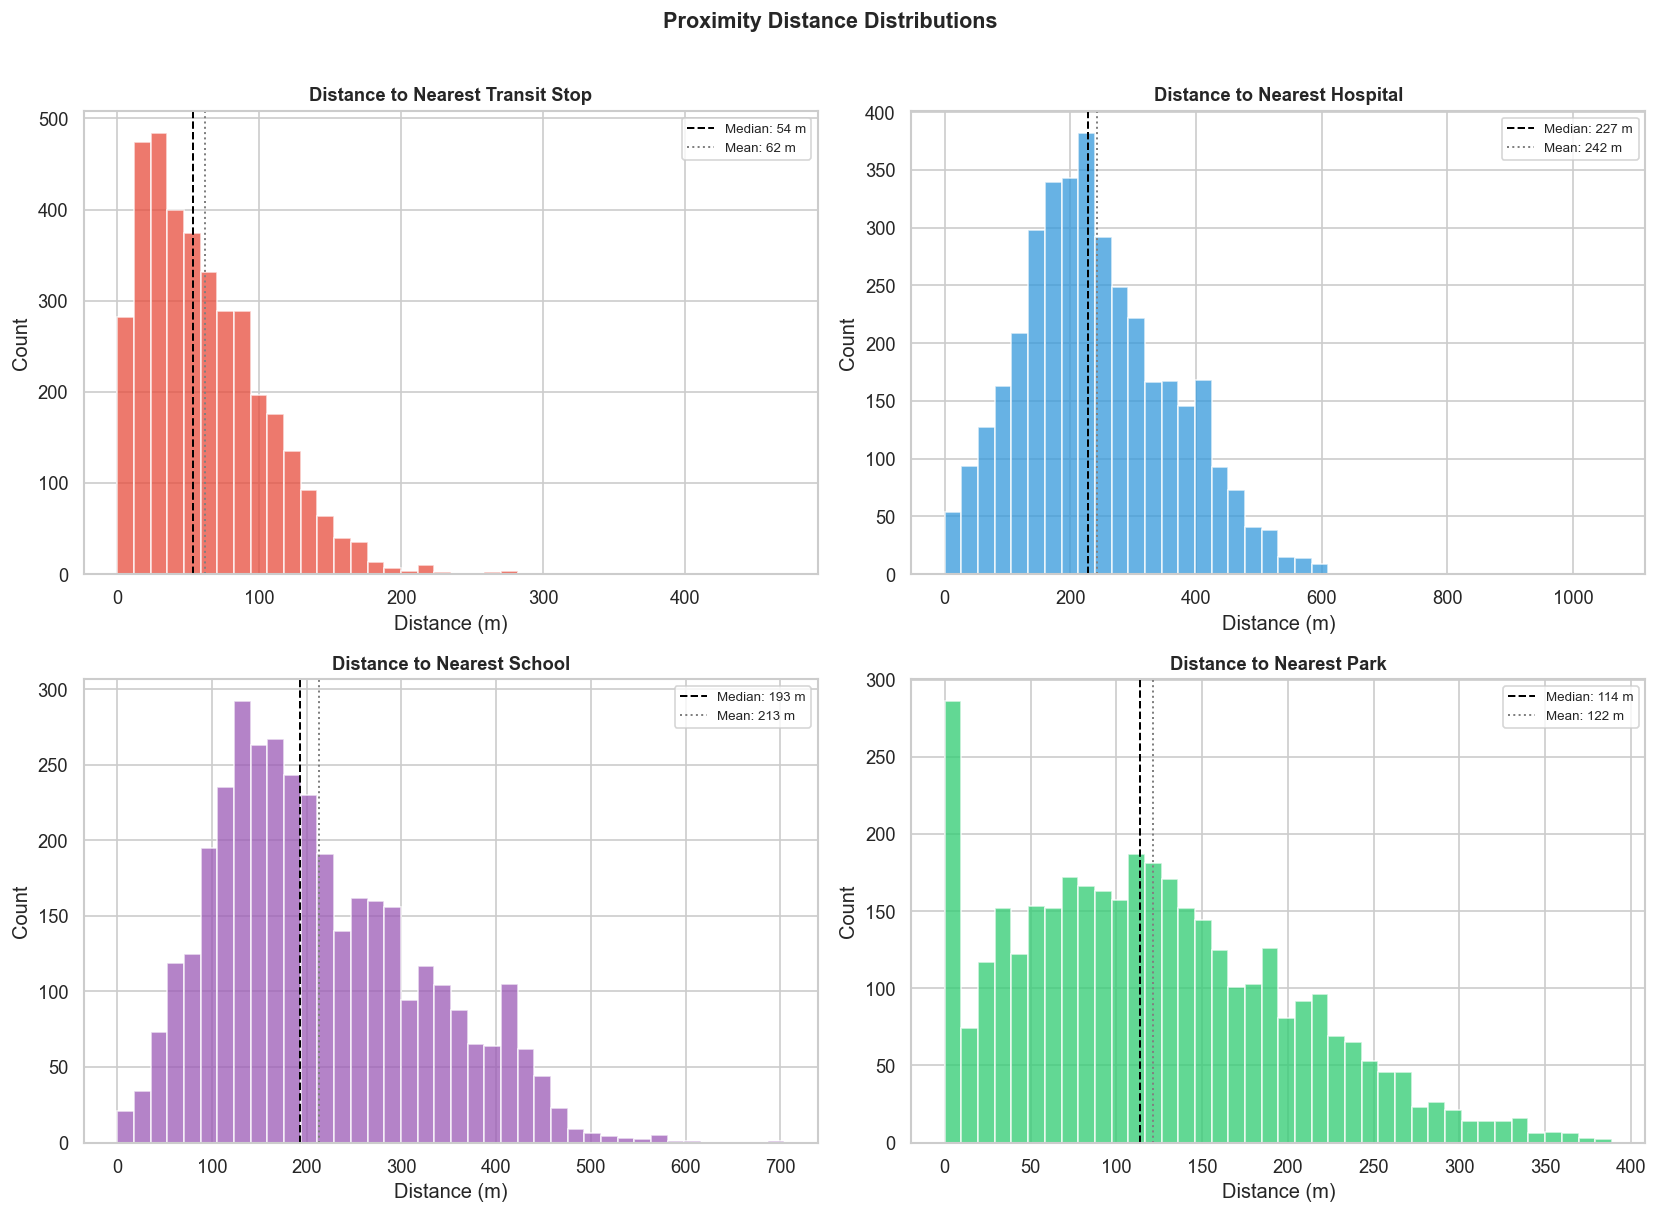

In [4]:
# ── Distance distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

prox_cols = {
    "dist_transit_m":  ("Distance to Nearest Transit Stop",  "#e74c3c"),
    "dist_hospital_m": ("Distance to Nearest Hospital",       "#3498db"),
    "dist_school_m":   ("Distance to Nearest School",         "#9b59b6"),
    "dist_park_m":     ("Distance to Nearest Park",           "#2ecc71"),
}

for ax, (col, (title, color)) in zip(axes.flat, prox_cols.items()):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1.2,
               label=f"Median: {data.median():.0f} m")
    ax.axvline(data.mean(),   color="gray",  linestyle=":",  linewidth=1.2,
               label=f"Mean: {data.mean():.0f} m")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Proximity Distance Distributions", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Cell 5 · Box Plots — Proximity by Tag Type

C:\Users\gramo\AppData\Local\Temp\ipykernel_39532\1870708931.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="primary_tag", y=col, order=order,
C:\Users\gramo\AppData\Local\Temp\ipykernel_39532\1870708931.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="primary_tag", y=col, order=order,
C:\Users\gramo\AppData\Local\Temp\ipykernel_39532\1870708931.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="primary_tag", y=col, order=order,
C:\Users\gramo\AppData\Local\Temp\ipykernel_39532\1870708931.py:13:

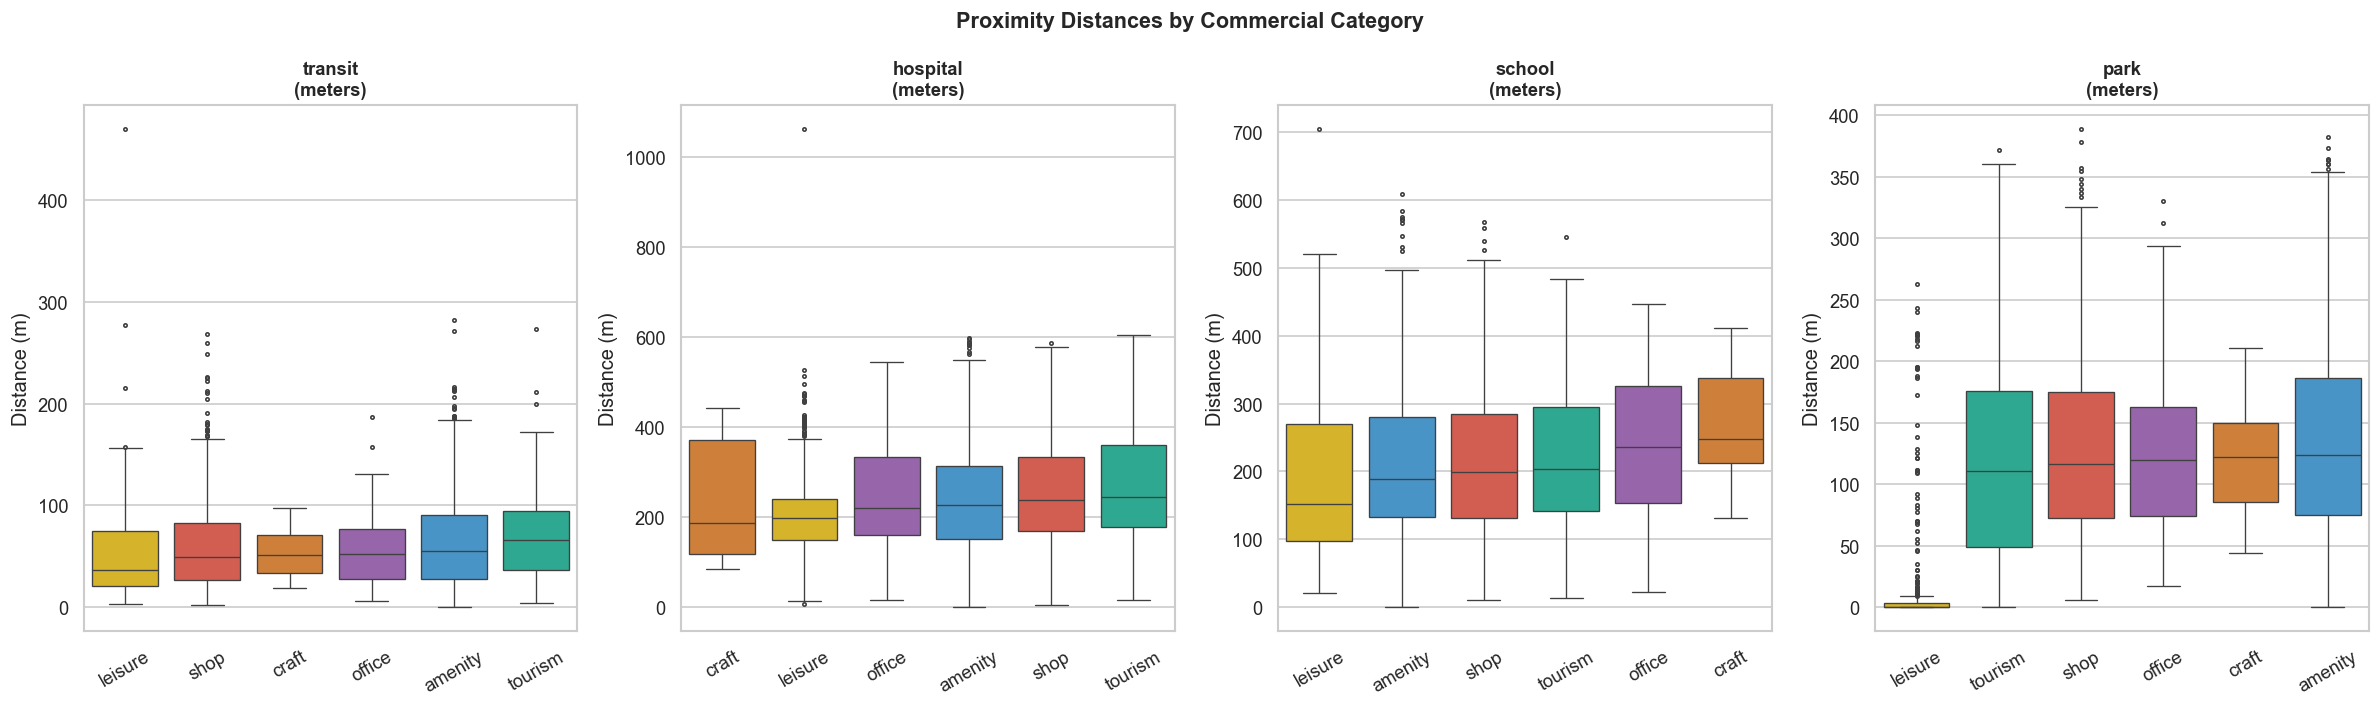

In [5]:
# ── Boxplot: proximity distances by primary_tag ───────────────────────────────
prox_cols = [c for c in ["dist_transit_m","dist_hospital_m","dist_school_m","dist_park_m"]
             if c in df.columns]

if prox_cols:
    fig, axes = plt.subplots(1, len(prox_cols), figsize=(5 * len(prox_cols), 6))
    if len(prox_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, prox_cols):
        order = df.groupby("primary_tag")[col].median().sort_values().index
        palette = {t: TAG_COLORS.get(t, "#95a5a6") for t in order}
        sns.boxplot(data=df, x="primary_tag", y=col, order=order,
                    palette=palette, ax=ax, linewidth=0.8, fliersize=2)
        ax.set_title(col.replace("_", " ").replace("dist ", "").replace(" m","\n(meters)"),
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Distance (m)")
        ax.tick_params(axis="x", rotation=30)

    plt.suptitle("Proximity Distances by Commercial Category", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## Cell 6 · Scatter — Origin Distance vs. Transit Proximity

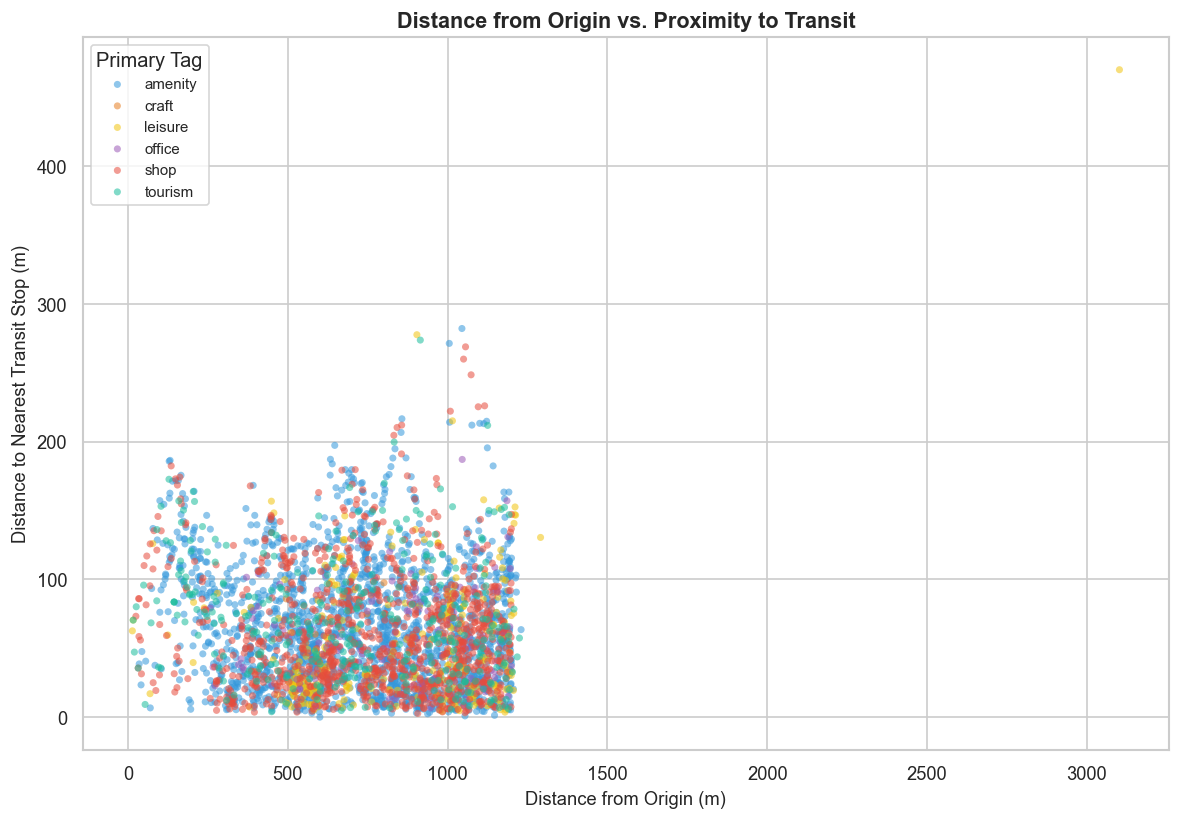

In [6]:
# ── Scatter: distance from origin vs distance to transit ─────────────────────
if "dist_transit_m" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 7))
    for tag, group in df.groupby("primary_tag"):
        ax.scatter(group["distance_m"], group["dist_transit_m"],
                   label=tag, color=TAG_COLORS.get(tag, "#95a5a6"),
                   alpha=0.55, s=18, edgecolors="none")
    ax.set_xlabel("Distance from Origin (m)", fontsize=11)
    ax.set_ylabel("Distance to Nearest Transit Stop (m)", fontsize=11)
    ax.set_title("Distance from Origin vs. Proximity to Transit", fontsize=13, fontweight="bold")
    ax.legend(title="Primary Tag", fontsize=9)
    plt.tight_layout()
    plt.show()


## Cell 7 · Correlation Matrix

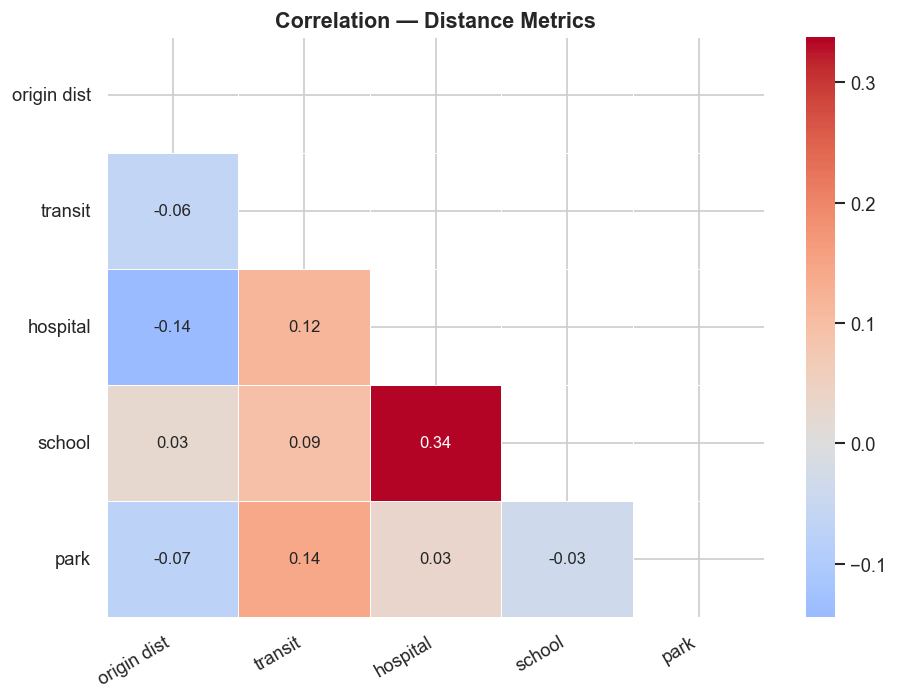

In [7]:
# ── Correlation matrix: proximity distances ───────────────────────────────────
num_cols = ["distance_m"] + [c for c in
            ["dist_transit_m","dist_hospital_m","dist_school_m","dist_park_m"]
            if c in df.columns]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Correlation — Distance Metrics", fontsize=13, fontweight="bold")
labels = [l.replace("dist_","").replace("_m","").replace("distance","origin dist")
          for l in num_cols]
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticklabels(labels, rotation=0)
plt.tight_layout()
plt.show()


## Cell 8 · Interactive Map

Clustered markers by category. Click any marker for details.
Toggle layers with the control in the top right.

In [8]:
# ── Interactive map: commercial features + proximity POIs ─────────────────────
# Color scheme: one color per primary_tag
# Marker size: proportional to nothing (uniform) — use cluster for density

m = folium.Map(
    location=[ORIGIN_LAT, ORIGIN_LON],
    zoom_start=15,
    tiles="CartoDB positron"
)

# Scrape radius circle
folium.Circle(
    location=[ORIGIN_LAT, ORIGIN_LON],
    radius=df["distance_m"].max(),
    color="#2c3e50", weight=1.5, fill=True, fill_opacity=0.04,
    tooltip="Commercial scrape radius"
).add_to(m)

# Origin marker
folium.Marker(
    location=[ORIGIN_LAT, ORIGIN_LON],
    icon=folium.Icon(color="black", icon="home", prefix="fa"),
    tooltip="Origin point"
).add_to(m)

# ── One MarkerCluster layer per primary_tag ──────────────────────────────────
for tag, group in df.groupby("primary_tag"):
    cluster = MarkerCluster(name=f"🏪 {tag.capitalize()} ({len(group)})",
                            show=True).add_to(m)
    hex_color = TAG_COLORS.get(tag, "#95a5a6")
    for _, row in group.iterrows():
        name_str = row['name'] if row['name'] else '(no name)'
        popup_html = (
            f"<b>{name_str}</b><br>"
            f"<i>{row['primary_tag']}: {row['primary_value']}</i><br>"
            f"Distance from origin: <b>{row['distance_m']:.0f} m</b><br>"
        )
        for prox in ["transit", "hospital", "school", "park"]:
            dc = f"dist_{prox}_m"
            nc = f"nearest_{prox}"
            if dc in row.index and pd.notna(row[dc]):
                near_name = row[nc] if (nc in row.index and pd.notna(row[nc]) and row[nc]) else ""
                popup_html += f"Nearest {prox}: <b>{row[dc]:.0f} m</b>"
                if near_name:
                    popup_html += f" ({near_name})"
                popup_html += "<br>"

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=5,
            color=hex_color,
            fill=True,
            fill_color=hex_color,
            fill_opacity=0.75,
            weight=0.5,
            popup=folium.Popup(popup_html, max_width=280),
            tooltip=row['name'] or row['primary_value'],
        ).add_to(cluster)

# Layer control + scale
folium.LayerControl(collapsed=False).add_to(m)
MeasureControl(primary_length_unit="meters").add_to(m)

m


## Cell 9 · Density Heatmap

Shows commercial feature concentration across the study area.

In [9]:
# ── Heatmap: commercial feature density ──────────────────────────────────────
heat_data = df[["lat", "lon"]].dropna().values.tolist()

m2 = folium.Map(
    location=[ORIGIN_LAT, ORIGIN_LON],
    zoom_start=15,
    tiles="CartoDB dark_matter"
)

HeatMap(
    heat_data,
    radius=18,
    blur=12,
    max_zoom=17,
    gradient={0.2: "#313695", 0.4: "#74add1", 0.6: "#fee090", 0.8: "#f46d43", 1.0: "#a50026"}
).add_to(m2)

folium.Circle(
    location=[ORIGIN_LAT, ORIGIN_LON],
    radius=df["distance_m"].max(),
    color="white", weight=1, fill=False,
).add_to(m2)

m2


## Cell 10 · Proximity Map — Colored by Distance to Transit

Green = close to transit · Red = far from transit.

In [10]:
# ── Map colored by distance to transit stop ───────────────────────────────────
if "dist_transit_m" in df.columns:
    col = "dist_transit_m"
    vmin, vmax = df[col].quantile(0.05), df[col].quantile(0.95)

    m3 = folium.Map(
        location=[ORIGIN_LAT, ORIGIN_LON],
        zoom_start=15,
        tiles="CartoDB positron"
    )

    cmap = cm.get_cmap("RdYlGn_r")

    for _, row in df.iterrows():
        if pd.isna(row[col]):
            continue
        norm_val = (row[col] - vmin) / max(vmax - vmin, 1)
        norm_val = max(0.0, min(1.0, norm_val))
        r, g, b, _ = cmap(norm_val)
        hex_col = "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=4,
            color=hex_col,
            fill=True,
            fill_color=hex_col,
            fill_opacity=0.8,
            weight=0,
            tooltip=f"{row['name'] or row['primary_value']} — {row[col]:.0f} m to transit",
        ).add_to(m3)

    folium.Marker(
        location=[ORIGIN_LAT, ORIGIN_LON],
        icon=folium.Icon(color="black", icon="home", prefix="fa"),
    ).add_to(m3)

    legend_html = (
        '<div style="position:fixed;bottom:30px;left:30px;z-index:999;background:white;'
        'padding:10px 14px;border-radius:8px;font-size:12px;box-shadow:2px 2px 6px rgba(0,0,0,0.3)">'
        '<b>Distance to Transit</b><br>'
        '<span style="color:#1a9641">&#9632;</span> Close<br>'
        '<span style="color:#fdae61">&#9632;</span> Medium<br>'
        '<span style="color:#d7191c">&#9632;</span> Far'
        '</div>'
    )
    m3.get_root().html.add_child(folium.Element(legend_html))
    m3


C:\Users\gramo\AppData\Local\Temp\ipykernel_39532\4104196504.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn_r")


## Cell 11 · Statistical Summary

In [11]:
# ── Statistical summary table ─────────────────────────────────────────────────
prox_cols = [c for c in ["dist_transit_m","dist_hospital_m","dist_school_m","dist_park_m"]
             if c in df.columns]

summary = df[prox_cols].describe().round(1).T
summary.columns = ["count","mean","std","min","25%","50%","75%","max"]
summary.index = [i.replace("dist_","").replace("_m","").replace("_"," ") for i in summary.index]
summary


,count,mean,std,min,25%,50%,75%,max
transit,3704.0,61.8,43.0,0.0,27.7,53.5,88.3,469.8
hospital,3704.0,242.4,119.0,0.0,158.2,227.3,319.8,1061.9
school,3704.0,213.0,109.0,0.0,130.9,192.6,285.0,704.4
park,3704.0,121.5,80.1,0.0,59.7,113.8,175.4,389.0
